<a href="https://colab.research.google.com/github/lack-of-sleep/2609Study/blob/main/17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 17**
텍스트로 이미지 생성하기

In [2]:
!pip install diffusers==0.12.1 transformers==4.19.2 ftfy accelerate

  Using cached diffusers-0.12.1-py3-none-any.whl.metadata (32 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 4.8 MB/s eta 0:00:00
  Using cached ftfy-6.3.1-py3-none-any.whl.metadata (7.3 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 20.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached diffusers-0.12.1-py3-none-any.whl (604 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 111.8 MB/s eta 0:00:00
Using cached ftfy-6.3.1-py3-none-any.whl (44 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERRO

In [3]:
import torch
from diffusers import StableDiffusionPipeline
#Diffusers에 있는 Stable Diffusion 모델 사용

model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda"
#사용 모델 ID 지정
#모델 연산 장치는 cuda(GPU)사용


#프롬프트 정의, 고갱스타일의 후지산
prompt = "Mt.Fuji in the style of Gauguin"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id, revision="fp16", torch_dtype=torch.float16)
#사전학습된 파이프라인 불러옴(모델ID, 모델버전, 모델데이터타입)

pipe = pipe.to(device)
#GPU로 전송

generator = torch.Generator(device).manual_seed(66) #생성기 생성, 시드값 설정
with torch.autocast("cuda"):
  image = pipe(prompt, guidance_scale=7.5, generator=generator).images[0]
#GPU에서 작업 수행(프롬프트, 프롬프트 반영도, 무작위성제어)images[0]에 저장

image.save("mt_fuji_gauguin.png")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:342: FutureWarning: You are loading the variant fp16 from CompVis/stable-diffusion-v1-4 via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that CompVis/stable-diffusion-v1-4 currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'CompVis/stable-diffusion-v1-4 is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

Mounted at /content/drive


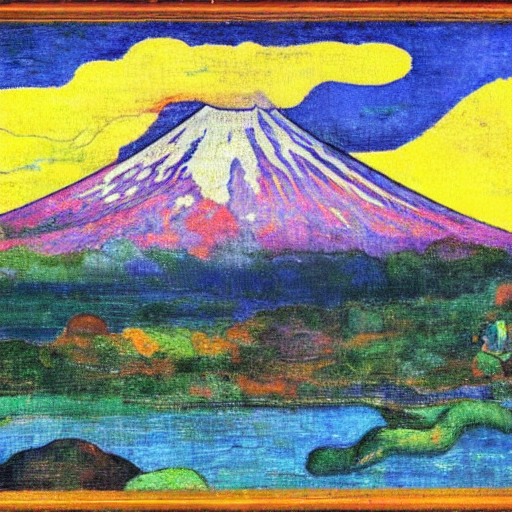

In [4]:
from google.colab import drive
drive.mount('/content/drive')

from IPython.display import Image, display

image_path = '/content/mt_fuji_gauguin.png'

display(Image(filename=image_path))

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/pipeline_loading_utils.py:342: FutureWarning: You are loading the variant fp16 from CompVis/stable-diffusion-v1-4 via `revision='fp16'`. This behavior is deprecated and will be removed in diffusers v1. One should use `variant='fp16'` instead. However, it appears that CompVis/stable-diffusion-v1-4 currently does not have the required variant filenames in the 'main' branch. 
 The Diffusers team and community would be very grateful if you could open an issue: https://github.com/huggingface/diffusers/issues/new with the title 'CompVis/stable-diffusion-v1-4 is missing fp16 files' so that the correct variant file can be added.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/2880f2ca379f41b0226444936bb7a6766a227587/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


  0%|          | 0/50 [00:00<?, ?it/s]

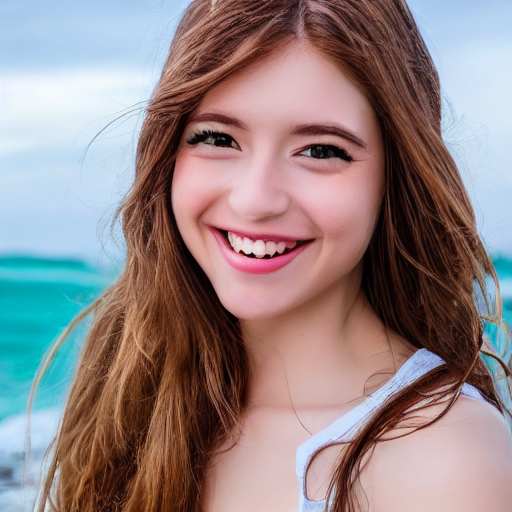

In [5]:
from numpy import negative
import torch
from diffusers import StableDiffusionPipeline

prompt = """
8k, RAW photo, good quality, realistic, clear, professional lighting, beautiful face,
BREAK
realistic disney princess, long hair, smile,
BREAK
mermaid,
BREAK
beach """

negative_prompt="""
bad anatomy, mutated hands, extra_arms, extra_legs, bad hands, disconnected_limbs, extra fingers, missing fingers, ugly face
"""

model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id, revision="fp16", torch_dtype=torch.float16)
pipe = pipe.to(device)

generator = torch.Generator(device).manual_seed(66)

with torch.autocast("cuda"):
  image = pipe(prompt, guidance_scale=7.5, generator=generator).images[0]

image.save("princess.png")

from IPython.display import Image, display

image_path = '/content/princess.png'

display(Image(filename=image_path))
